# Bin2cell QC & Filtering — Liver (deep-sequenced) Samples

**Purpose:** Quality-check the per-spot/per-bin count distributions produced by
[Bin2cell](https://github.com/Teichlab/bin2cell) on Visium HD data, then filter
out low-count bins before downstream analysis (e.g. Tangram deconvolution).

**Filtering threshold used (chosen empirically for this dataset):**
- Liver (2 µm bins, Bin2cell output): keep bins with `bin_count > 2`

**Inputs:**
- Sample sheet: `bin2cell_samp_md_reruns.txt` (library IDs + paths to
  Space Ranger / Bin2cell outputs per sample)
- Per-library Bin2cell `.h5ad` files: `<b2c_dir>/<library_id>/<library_id>_cdata_b2c.h5ad`

**Outputs:**
- QC plots (histograms + violin plots of counts per bin) as PDFs
- Filtered `.h5ad` files per library, written to a `filt_deep*` output directory

**Cleanup notes:** removed dead/commented-out exploratory code, duplicate
import and directory-assignment cells, an unrelated scratch check of a
Tangram reference `.h5ad` file, and an unfinished/never-run generic filtering
helper (it pointed at a placeholder `/path/to/output/files`). Also removed a
second sample set (heart samples) that this notebook originally processed
alongside liver, since it shared the same code but isn't part of this
notebook's scope. No liver analysis logic that produces saved outputs was
changed; a couple of `os.mkdir()` calls were switched to
`os.makedirs(..., exist_ok=True)` so the notebook can be re-run without
crashing on existing directories.

In [26]:
# Core libraries
import os
import re

import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

import bin2cell as b2c


## Configuration

In [22]:
# Directory containing per-library Bin2cell outputs (<library_id>/<library_id>_cdata_b2c.h5ad)
b2c_dir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/'


## Load sample sheet

In [21]:
# Sample sheet mapping library_id -> patient_id and raw Space Ranger / image paths.
# This is the "reruns" version of the sheet (supersedes an earlier draft sample sheet).
samp_sheet = pd.read_csv(
    '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/scripts/bin2cell/bin2cell_samp_md_reruns.txt',
    sep='\t',
)


In [22]:
samp_sheet

,library_id,patient_id,condition,image_path,spaceranger_micron2_path,spaceranger_spatial_dir_path,mpp
0,QY_2645_1_2_3,HL180809,Normal,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
1,QY_2665_1_2,HL160029,Normal,/tscc/projects/ps-epigen/10x_output/Space_Rang...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
2,QY_2666_1_2,HL170058,MASH,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
3,QY_2673_1_2,HL230324,MASL,/tscc/projects/ps-epigen/10x_output/Space_Rang...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
4,QY_2674_1_2,HL230325,NASH_ALD,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
5,JL_104_2_3,HL221006,MASH,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
6,QY_2667_1_2,DVL9,CONTROL,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
7,QY_2668_1_2,DTX37-LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
8,QY_2720_2,OC_LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
9,QY_2721_2,T8_LVA,ICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25


## Liver samples — QC plots

Two sample subsets are defined below (only run the one relevant to your QC
pass, since each reassigns `samp_sheet_liver`):
- **Option A** — the main liver batch.
- **Option B** — a single library (`QY_2666_1_2`) processed in a later rerun.

As written, running both cells sequentially means Option B's single-sample
subset is what actually gets used by the QC loop further down; re-run Option A
alone if you want QC plots for the full main batch instead.

In [40]:
# Option A: main liver batch
samp_sheet_liver = samp_sheet[samp_sheet['library_id'].isin([
    'QY_2645_1_2_3', 'QY_2665_1_2', 'QY_2673_1_2', 'QY_2674_1_2', 'JL_104_2_3',
])]
# Other liver library IDs available in the sample sheet, not included here:
# JL_101_1_2_3, QY_2666_1_2


In [23]:
# Option B: liver library processed in a later rerun (overwrites samp_sheet_liver above)
samp_sheet_liver = samp_sheet[samp_sheet['library_id'].isin([
    'QY_2666_1_2',
])]


In [24]:
samp_sheet_liver

,library_id,patient_id,condition,image_path,spaceranger_micron2_path,spaceranger_spatial_dir_path,mpp
2,QY_2666_1_2,HL170058,MASH,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25


In [28]:
# Output directory for QC plots (liver, deep-sequenced batch)
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Heart/outputs/sandbox/qc_plots_deep/'


In [30]:
os.makedirs(outdir, exist_ok=True)


### QC plotting helper functions

In [32]:
def plot_qc_metrics_hist(anndata_obj, outdir, library_id, count_md):
    """Plot and save a histogram of a per-bin/per-cell count metric, with a
    dashed line marking the mean.

    Parameters
    ----------
    anndata_obj : AnnData
        Object whose `.obs[count_md]` holds the count metric to plot.
    outdir : str
        Directory to save the resulting PDF into.
    library_id : str
        Sample/library identifier, used to name the output file.
    count_md : str
        Column name in `anndata_obj.obs` holding the count metric
        (e.g. "bin_count", "n_counts").
    """
    average_counts_per_cell = anndata_obj.obs[count_md].mean()

    plt.hist(anndata_obj.obs[count_md], bins=50)
    plt.axvline(average_counts_per_cell, color='r', linestyle='dashed', linewidth=2)
    plt.title('Distribution of Total Counts per Cell with Average')
    plt.xlabel('Total Counts')
    plt.ylabel('Frequency')

    plt.savefig(f"{outdir}{library_id}_hist_{count_md}.pdf")


In [33]:
def plot_qc_metrics_vln(anndata_obj, outdir, library_id, count_md):
    """Plot and save a violin plot of a per-bin/per-cell count metric,
    annotated with mean, median, and number of cells/bins.

    Parameters
    ----------
    anndata_obj : AnnData
        Object whose `.obs[count_md]` holds the count metric to plot.
    outdir : str
        Directory to save the resulting PDF into.
    library_id : str
        Sample/library identifier, used to name the output file.
    count_md : str
        Column name in `anndata_obj.obs` holding the count metric
        (e.g. "bin_count", "n_counts").
    """
    average_counts_per_cell = anndata_obj.obs[count_md].mean()
    median_counts_per_cell = anndata_obj.obs[count_md].median()
    print(f"Average counts per cell: {average_counts_per_cell}")

    fig, ax = plt.subplots(figsize=(8, 6))
    num_cells = anndata_obj.n_obs

    sc.pl.violin(anndata_obj, ax=ax, keys=count_md, rotation=45, jitter=0.4, show=False)

    ax.axhline(average_counts_per_cell, color="red", linestyle="--", label=f"Mean: {average_counts_per_cell:.2f}")
    ax.axhline(median_counts_per_cell, color="purple", linestyle="--", label=f"Median: {median_counts_per_cell:.2f}")

    ax.text(0.1, average_counts_per_cell, f"Mean: {average_counts_per_cell:.2f}",
            color="red", ha="center", va="center", backgroundcolor="white")
    ax.text(0.1, median_counts_per_cell, f"Median: {median_counts_per_cell:.2f}",
            color="purple", ha="center", va="center", backgroundcolor="white")
    ax.legend()

    ax.text(0.95, 0.95, f'Number of Cells: {num_cells}',
            transform=ax.transAxes, ha='right', va='top', color='black', fontsize=12)

    plt.savefig(f"{outdir}{library_id}_vlnplt_{count_md}.pdf")


### Generate QC plots for each liver library

For each library in `samp_sheet_liver`, load the Bin2cell output and plot the `bin_count` distribution (histogram + violin).

Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2666_1_2_3/outs/binned_outputs/square_008um/
QY_2666_1_2
AnnData object with n_obs × n_vars = 771412 × 18035
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'labels_joint_source_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped'
Average counts per cell: 9.07822019880427


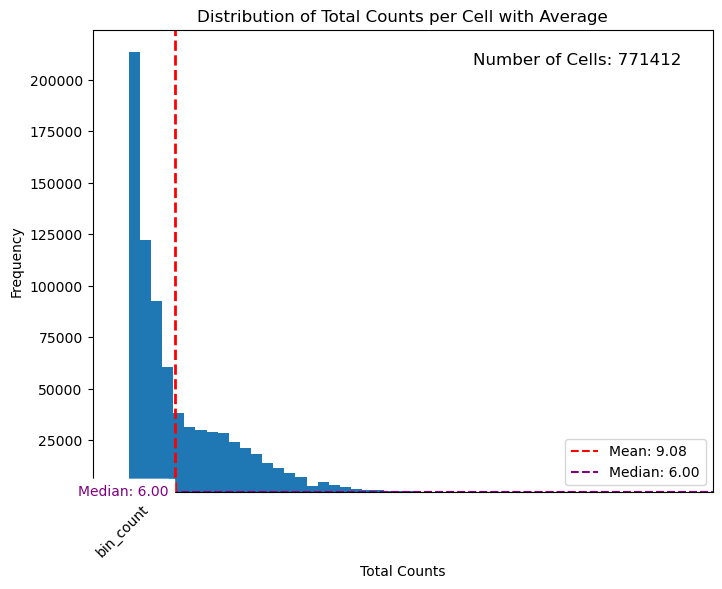

In [36]:
for index, row in samp_sheet_liver.iterrows():
    library_id = row['library_id']
    patient_id = row['patient_id']

    # Space Ranger paths are recorded in the sample sheet but aren't needed here,
    # since QC below is run on the Bin2cell (post-binning) output rather than
    # the raw Space Ranger square_002um/square_008um bins.
    two_mic_path = row['spaceranger_micron2_path']
    two_mic_path = re.sub('square_002um', 'square_008um', two_mic_path)
    print(f"Two micron path: {two_mic_path}")

    print(library_id)

    adata_2725_b2c = sc.read_h5ad(f"{b2c_dir}{library_id}/{library_id}_cdata_b2c.h5ad")
    print(adata_2725_b2c)

    plot_qc_metrics_vln(adata_2725_b2c, outdir, library_id, 'bin_count')
    plot_qc_metrics_hist(adata_2725_b2c, outdir, library_id, 'bin_count')


## Liver samples — filtering

Filter each library's Bin2cell output to `bin_count > 2` (chosen empirically to be conservative for this liver dataset) and write the filtered `.h5ad` files out for downstream use.

In [45]:
os.makedirs(
    '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt_deep/',
    exist_ok=True,
)


In [43]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt_deep/'


In [40]:
# Liver: keep bins with bin_count > 2
for index, row in samp_sheet_liver.iterrows():
    library_id = row['library_id']
    print(f"Library ID: {library_id}")

    ad_sp_b2c = sc.read_h5ad(f"{b2c_dir}{library_id}/{library_id}_cdata_b2c.h5ad")
    print(ad_sp_b2c)

    ad_sp_b2c_filt = ad_sp_b2c[ad_sp_b2c.obs['bin_count'] > 2].copy()
    print(ad_sp_b2c_filt)
    print(ad_sp_b2c_filt.n_obs / ad_sp_b2c.n_obs)  # fraction of bins retained

    ad_sp_b2c_filt.write_h5ad(f"{outdir}{library_id}_cdata_b2c_filt_2ct.h5ad")


Library ID: QY_2666_1_2
AnnData object with n_obs × n_vars = 771412 × 18035
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'labels_joint_source_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped'
AnnData object with n_obs × n_vars = 557770 × 18035
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'labels_joint_source_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped'
0.7230507173857809
